# MTM1 / Snx17 ODE model — YAML parameters

Keep `ode_parameters.yaml`, this notebook, and your existing `cargo_for_plot.csv` in the same folder. Start Jupyter in that folder, or set `CONFIG_PATH` below to the YAML's full path.

If PyYAML is missing, run `%pip install pyyaml` in a notebook cell once. Edit the YAML, then **Restart Kernel and Run All** to apply changes.

The YAML holds affinities, geometry, rate settings, initial concentrations, membrane composition, run times, solver settings, and input/output names. Derived rates remain in Python; the original equations and assay initialisation are retained. `keff_SM` and `keff_MM` inherit `keff_M` when set to `null`. Catalytic coefficient units are nM⁻¹ s⁻¹ for the current equations.

The original reference-based dissociation formulas are preserved exactly; changing `kon` alone does not automatically update `koff`. The experimental CSV is still required. Old outputs have been cleared so plots cannot be mistaken for a new run.


In [1]:
import sys
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import pandas as pd
import csv

# S = Snx17
# M = MTM1
# P = ProbeN
# A = Pi3P
# B = Pi
# C = Cargo



In [2]:
from pathlib import Path
import yaml

# Keep the YAML beside this notebook and start Jupyter in that folder.
# If needed, replace this with the full path to your YAML file.
CONFIG_PATH = Path("ode_parameters.yaml").resolve()
with CONFIG_PATH.open(encoding="utf-8") as f:
    config = yaml.safe_load(f)

affinities = config["affinities"]
Volume = config["geometry"]["Volume"]
TotalMembraneSA = config["geometry"]["TotalMembraneSA"]

keff_M = config["catalysis"]["keff_M"]
keff_SM = config["catalysis"]["keff_SM"]
keff_MM = config["catalysis"]["keff_MM"]
if keff_SM is None:
    keff_SM = keff_M
if keff_MM is None:
    keff_MM = keff_M

params = dict(config["association_rates"])
ref = config["dissociation_reference"]
for suffix, kd_name in [("SA", "Kd_SA"), ("MA", "Kd_MA"),
                        ("PA", "Kd_PA"), ("PB", "Kd_PB"),
                        ("MMf", "Kd_MM_3D")]:
    reference_koff = ref["probe_A_koff"] if suffix == "PA" else ref["bulk_koff"]
    params["koff_" + suffix] = reference_koff * (affinities[kd_name] / ref["bulk_Kd"])
for suffix, kd_name in [("SM", "Kd_SM"), ("SC", "Kd_SC"), ("MMa", "Kd_MM_2D")]:
    params["koff_" + suffix] = ref["surface_koff"] * (affinities[kd_name] / ref["surface_Kd"])

divisors = config["complex_off_rate_divisors"]
params["koff_SAM"] = params["koff_SA"] / divisors["SAM"]
params["koff_SAC"] = params["koff_SA"] / divisors["SAC"]
params["koff_MAM"] = params["koff_MA"] / divisors["MAM"]
params.update(keff_M=keff_M, keff_SM=keff_SM, keff_MM=keff_MM,
              ka=config["transport"]["ka"])

eq_Snx17_conc = config["equilibration"]["Snx17_conc"]
eq_MTM1_conc = config["equilibration"]["MTM1_conc"]
eq_Probe_conc = config["equilibration"]["Probe_conc"]
eq_cargo_conc = config["equilibration"]["cargo_fraction"]
PC_concentration = config["membrane"]["PC_concentration"]
membrane_substrate = config["membrane"]["membrane_substrate"]
membrane_product = config["membrane"]["membrane_product"]
equilibration_time = config["equilibration"]["time_s"]
initial_Snx17_conc = config["assay"]["Snx17_conc"]
initial_MTM1_conc = config["assay"]["MTM1_conc"]
initial_Probe_conc = config["assay"]["Probe_conc"]
simulation_time = config["assay"]["time_s"]
solver_options = dict(config["solver"])
file_settings = config["files"]
experimental_csv = CONFIG_PATH.parent / file_settings["experimental_csv"]
results_csv = CONFIG_PATH.parent / file_settings["results_csv"]


In [3]:
df = pd.read_csv(experimental_csv)
df_time = (df[file_settings["time_column"]] * file_settings["time_to_seconds"]).tolist()
df_50M = df[file_settings["WT_column"]].tolist()
df_25M = df[file_settings["AAAA_column"]].tolist()


In [4]:
equilibration_concentrations = [
    0, # Sa
    0, # Ma
    0, # Pa
    eq_Snx17_conc, # Sf
    eq_MTM1_conc, # Mf
    eq_Probe_conc, # Pf
    0, # SbA
    0, # MbA
    0, # PbA
    0, # PbB
    0, # SMb
    0, # SbC
    0, # MMf
    0, # MMb
    PC_concentration * membrane_substrate, # A
    PC_concentration * membrane_product, # B
    PC_concentration * eq_cargo_conc # C
]

# ===================== ODE Model =====================

def change_in_bidning(kon, substrate,
                      koff, free_form, bound_form):
    
    return kon * substrate * free_form - koff * bound_form

#trajectory_arrays = []
def model(t, y):
    global params
    Sa, Ma, Pa, Sf, Mf, Pf, SbA, MbA, PbA, PbB, SMb, SbC, MMf, MMb, A, B, C = y

    kon_SA   = params["kon_SA"]
    koff_SA  = params["koff_SA"]
    kon_MA   = params["kon_MA"]
    koff_MA  = params["koff_MA"]
    kon_PA   = params["kon_PA"]
    koff_PA  = params["koff_PA"]
    kon_PB   = params["kon_PB"]
    koff_PB  = params["koff_PB"]
    kon_SM   = params["kon_SM"]
    koff_SM  = params["koff_SM"]
    koff_SAM = params["koff_SAM"]
    kon_SC   = params["kon_SC"]
    koff_SC  = params["koff_SC"]
    koff_SAC = params["koff_SAC"]
    kon_MMf = params["kon_MMf"]
    koff_MMf = params["koff_MMf"]
    kon_MMa = params["kon_MMa"]
    koff_MMa = params["koff_MMa"]
    kon_MAM = params["kon_MAM"]
    koff_MAM = params["koff_MAM"]
    keff_M   = params["keff_M"]
    keff_SM  = params["keff_SM"]
    keff_MM  = params["keff_MM"]
    ka       = params["ka"]

    # =================================== ODE equations
    # Free lipid/cargo available for binding
    A_bind = max((A - SbA - MbA - PbA - (SMb*2) - SbC - (MMb*2)), 0.0) # ensures that [Pi3P] can never fall below 0nM
    B_bind = max((B - PbB), 0.0) # ensures that [Pi] can never fall below 0nM
    C_bind = max((C - SbC), 0.0) # ensures that [Cargo] can never fall below 0nM

    
    # Convert nM to molecules/um2 for 2D binding calculations
    aMbA = ((MbA * 0.602) * Volume) / TotalMembraneSA # molecules/um2 ([nM] * 0.602 = molecules per um3)
    aSbA = ((SbA * 0.602) * Volume) / TotalMembraneSA # molecules/um2 
    aSMb = ((SMb * 0.602) * Volume) / TotalMembraneSA # molecules/um2
    aC_bind = ((C_bind * 0.602) * Volume) / TotalMembraneSA # molecules/um2
    aSbC = ((SbC * 0.602) * Volume) / TotalMembraneSA # molecules/um2
    aMMb = ((MMb * 0.602) * Volume) / TotalMembraneSA # molecules/um2

    # 2D reaction rates (molecules/um2/s)
    # S·A + M·A <-> SM (both membrane-bound)
    SMb_rate_mum2 = change_in_bidning(kon_SM, aMbA, koff_SM, aSbA, aSMb)
    
    # S·A + C <-> S·A·C  (S must already be membrane-bound via A)
    SbC_rate_mum2 = change_in_bidning(kon_SC, aC_bind, koff_SC, aSbA, aSbC)

    # M·A + M·A <-> MM (both membrane-bound)
    MMb_rate_mum2 = change_in_bidning(kon_MMa, aMbA, koff_MMa, aMbA, aMMb)
    
    # Convert 2D rates back to nM/s
    SMb_rate_nM = (SMb_rate_mum2 * TotalMembraneSA) / (0.602 * Volume)
    SbC_rate_nM = (SbC_rate_mum2 * TotalMembraneSA) / (0.602 * Volume)
    MMb_rate_nM = (MMb_rate_mum2 * TotalMembraneSA) / (0.602 * Volume)

    
    # Diffusion from compartment 1 -> compartment 2
    dSa = -(ka * Sa)
    dMa = -(ka * Ma)
    dPa = -(ka * Pa)

    
    # Calculating state changes in compartment 2
    # Free S, M, and P
    dSf = -change_in_bidning(kon_SA, A_bind, koff_SA, Sf, SbA) + \
          (koff_SAC * SbC) + \
          (koff_SAM * SMb) + (ka * Sa)
    
    dMf = -change_in_bidning(kon_MA, A_bind, koff_MA, Mf, MbA) + \
          (koff_SAM * SMb) + (ka * Ma) + \
          (-change_in_bidning(kon_MMf, Mf, koff_MMf, Mf, MMf) * 2)
    
    dPf = -change_in_bidning(kon_PA, A_bind, koff_PA, Pf, PbA) + \
          -change_in_bidning(kon_PB, B_bind, koff_PB, Pf, PbB) + (ka * Pa)

    dMMf = change_in_bidning(kon_MMf, Mf, koff_MMf, Mf, MMf) + \
          -change_in_bidning(kon_MAM, A_bind, koff_MAM, MMf, MMb)
    #print(dMMf, -change_in_bidning(kon_MAM, A_bind, koff_MAM, MMf, MMb), kon_MAM, A_bind, koff_MAM, MMf, MMb)


    # Binding from compartment 2 -> compartment 3
    dSbA = change_in_bidning(kon_SA, A_bind, koff_SA, Sf, SbA) + \
          -SMb_rate_nM + \
          -SbC_rate_nM

    dMbA = change_in_bidning(kon_MA, A_bind, koff_MA, Mf, MbA) + \
          -SMb_rate_nM - (2 * MMb_rate_nM)
    
    dPbA = change_in_bidning(kon_PA, A_bind, koff_PA, Pf, PbA)
    
    dPbB = change_in_bidning(kon_PB, B_bind, koff_PB, Pf, PbB)

    
    # SAM complex
    dSMb = SMb_rate_nM -(koff_SAM * SMb)

    # SAC complex
    dSbC = SbC_rate_nM -(koff_SAC * SbC)

    # MAM complex
    dMMb = change_in_bidning(kon_MAM, A_bind, koff_MAM, MMf, MMb) + MMb_rate_nM
    #print(dMMb)
    #print(dMMb, MMb_rate_nM, kon_MAM, A_bind, koff_MAM, MMf, MMb)

    # Catalysis: Pi3P -> Pi
    dB = (keff_M * MbA * A_bind) + (keff_SM * SMb * A_bind) + (keff_MM * 2 * MMb * A_bind)
    dA = -dB

    #trajectory_arrays.append([dSa, dMa, dPa, dSf, dMf, dPf, dSbA, dMbA, dPbA, dPbB, dSMb, dSbC, dA, dB])
    
    return [dSa, dMa, dPa, dSf, dMf, dPf, dSbA, dMbA, dPbA, dPbB, dSMb, dSbC, dMMf, dMMb, dA, dB, 0]



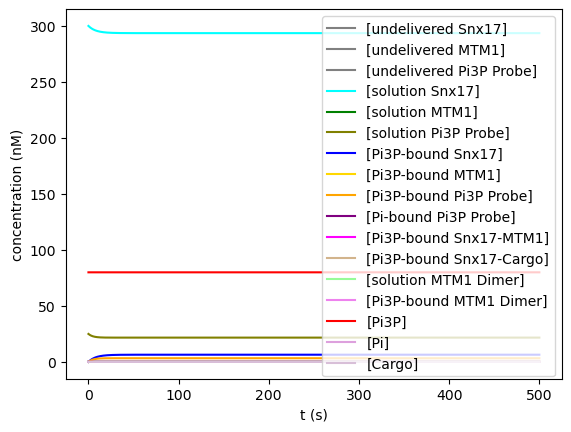

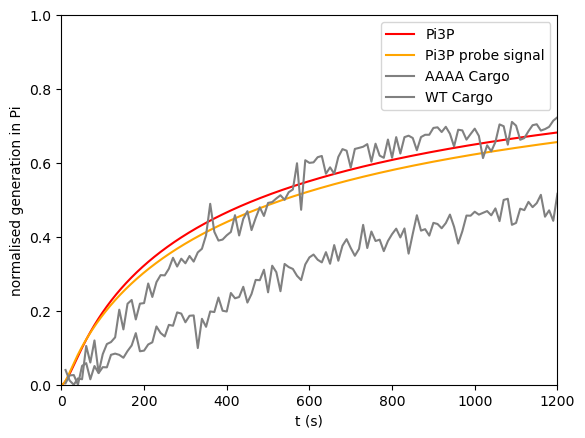

Final Simulated Trajectories:
[undelivered Snx17] 0.0
[undelivered MTM1] 0.0
[undelivered Pi3P Probe] 0.0
[solution Snx17] 297.85451407688663
[solution MTM1] 30.790863733906317
[solution Pi3P Probe] 23.840647706697748
[Pi3P-bound Snx17] 2.036718350592874
[Pi3P-bound MTM1] 0.012856345283918017
[Pi3P-bound Pi3P Probe] 1.131254328445731
[Pi-bound Pi3P Probe] 0.028097964855298703
[Pi3P-bound Snx17-MTM1] 0.1087675725426948
[Pi3P-bound Snx17-Cargo] 0.0
[solution MTM1 Dimer] 9.49755990207126
[Pi3P-bound MTM1 Dimer] 0.046196272062254656
[Pi3P] 25.399018997115782
[Pi] 54.60098100288433
[Cargo] 0.0


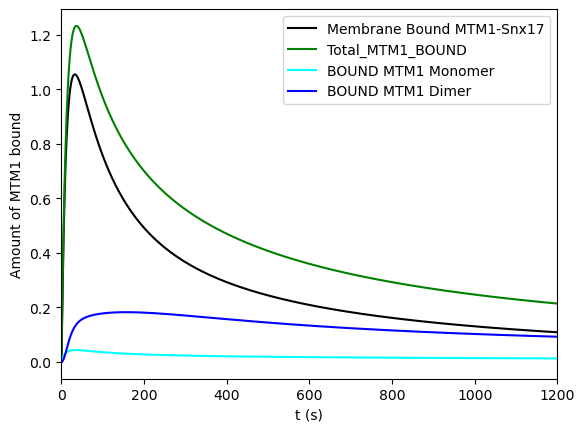

In [5]:
# ===================== Run =====================

label_list = ["[undelivered Snx17]", "[undelivered MTM1]", "[undelivered Pi3P Probe]", "[solution Snx17]", "[solution MTM1]", "[solution Pi3P Probe]",
              "[Pi3P-bound Snx17]", "[Pi3P-bound MTM1]", "[Pi3P-bound Pi3P Probe]", "[Pi-bound Pi3P Probe]", "[Pi3P-bound Snx17-MTM1]",
              "[Pi3P-bound Snx17-Cargo]", "[solution MTM1 Dimer]", "[Pi3P-bound MTM1 Dimer]", "[Pi3P]", "[Pi]", "[Cargo]"]
colour_list = ["grey", "grey", "grey", "cyan", "green", "olive", "blue", "gold",
              "orange", "purple", "fuchsia", "tan", "palegreen", "violet", "red", "plum", "thistle"]

# Pre-equilibriation
sol = solve_ivp(fun = model,
               t_span = equilibration_time,
               y0 = equilibration_concentrations,
               **solver_options)
y_EQ = sol.y[:, -1]

#========================= EQ plot

plt.figure()
for i in range(sol.y.shape[0]):
    plt.plot(sol.t, sol.y[i], label=label_list[i], c=colour_list[i])
plt.xlabel('t (s)') # the horizontal axis represents the time
plt.ylabel('concentration (nM)') # the vertical axis represents the concentration
plt.legend() # show how the colors correspond to the components of X
plt.show()


#print("Final Equilibriated Trajectories:")
#for component_no in enumerate(sol.y[:, -1]):
#    print(label_list[component_no[0]], (max((sol.y[:, -1][component_no[0]]), 0.0)))


assay_concentrations = [
    0, # Sa
    0, # Ma
    0, # Pa
    initial_Snx17_conc, # Sf
    initial_MTM1_conc, # Mf
    initial_Probe_conc, # Pf
    0, # SbA
    0, # MbA
    0, # PbA
    0, # PbB
    0, # SMb
    0, # SbC
    0, # MMf
    0, # MMb
    PC_concentration * membrane_substrate, # A
    PC_concentration * membrane_product, # B
    PC_concentration * eq_cargo_conc, # C
]

for component_no in enumerate(y_EQ):
    if component_no[1] > 0.0:
        assay_concentrations[component_no[0]] = component_no[1]


# assay simulation
sol = solve_ivp(fun = model,
               t_span = simulation_time,
               y0 = assay_concentrations,
               **solver_options)

#========================= Assay plot

##plt.figure()
##for i in range(sol.y.shape[0]):
##    plt.plot(sol.t, sol.y[i], label=label_list[i], c=colour_list[i])
##plt.xlabel('t (s)') # the horizontal axis represents the time
##plt.ylabel('concentration (nM)') # the vertical axis represents the concentration
##plt.legend() # show how the colors correspond to the components of X
##plt.show()


#========================= Normalised Pi3P plot

normalised_A = []
max_A = max(sol.y[14])
for n in sol.y[14]:
    normalised_A.append(1-(n/max_A))
#print("Final Normalised Pi3P", normalised_A[-1])

normalised_PbA = []
max_PbA = max(sol.y[8])
for n in sol.y[8]:
    normalised_PbA.append(1-(n/max_PbA))
#print("Final Normalised Probe", normalised_PbA[-1])

plt.figure()
plt.plot(sol.t, normalised_A, label="Pi3P", c=colour_list[14])
plt.plot(sol.t, normalised_PbA, label="Pi3P probe signal", c=colour_list[8])

plt.plot(df_time, df_25M, label="AAAA Cargo", c="grey")#"25nM MTM1", c="grey")
plt.plot(df_time, df_50M, label="WT Cargo", c="grey")#"50nM MTM1", c="grey")
#plt.plot(df_time, df_25MS, label="25nM MTM1", c="grey")#"25nM MTM1 + 300nM Snx17", c="grey")
#plt.plot(df_time, df_50MS, label="12.5nM MTM1", c="grey")#"50nM MTM1 + 300nM Snx17", c="grey")

plt.ylim(0, 1)
plt.xlim(*simulation_time)
plt.xlabel('t (s)') # the horizontal axis represents the time
plt.ylabel('normalised generation in Pi') # the vertical axis represents the normalised chnage in concentration
plt.legend() # show how the colors correspond to the components of X
plt.show()

#========================= CSV outputs

with results_csv.open("w", newline="") as f:
    writer = csv.writer(f)

    # Header row
    writer.writerow(["time (s)", "Pi3P_norm", "2xPX_norm"])

    # Data rows
    writer.writerows(zip(sol.t, normalised_A, normalised_PbA))

#with open("results_rates.csv", "w", newline="") as f:
#    writer = csv.writer(f)
#    # Header row
#    writer.writerow(["dSa", "dMa", "dPa", "dSf", "dMf", "dPf", "dSbA", "dMbA", "dPbA", "dPbB", "dSMb", "dSbC", "dA", "dB"])
#    # Data rows
#    writer.writerows(trajectory_arrays)

#print("Final Simulated Trajectories:")
#y_final = sol.y[:, -1]
#for component_no in enumerate(sol.y[:, -1]):
#    print(label_list[component_no[0]], (max((sol.y[:, -1][component_no[0]]), 0.0)))



#========================= MTM1 Bound PLot

#plot_M_free = []
#plot_M_bound = []
#plot_M_tot = []
#plot_Mf = []
#plot_Mb = []
#plot_SM = []
#plot_SA = []
#plot_MMf = []
#plot_MMb = []
##plot_Mb = max(sol.y[7])
##plot_SM = max(sol.y[10])

#for component_no in enumerate(sol.y[7]):
#    plot_M_tot.append(sol.y[4][component_no[0]] + sol.y[7][component_no[0]] + sol.y[10][component_no[0]] + (sol.y[12][component_no[0]]*2) + (sol.y[13][component_no[0]]*2))
#    plot_M_free.append(sol.y[4][component_no[0]] + (sol.y[12][component_no[0]]*2))
#    plot_M_bound.append(sol.y[7][component_no[0]] + sol.y[10][component_no[0]] + (sol.y[13][component_no[0]]*2))
#    plot_Mf.append(sol.y[4][component_no[0]])
#    plot_Mb.append(sol.y[7][component_no[0]])
#    plot_SM.append(sol.y[10][component_no[0]])
#    plot_SA.append(sol.y[6][component_no[0]])
#    plot_MMf.append(sol.y[12][component_no[0]]*2)
#    plot_MMb.append(sol.y[13][component_no[0]]*2)
#    #print("a", sol.y[7])
#    #print("b", component_no[0])

#plt.figure()
#plt.plot(sol.t, plot_SM, label="Membrane Bound MTM1-Snx17", c="black")
##plt.plot(sol.t, plot_SA, label="Monomer Membrane Bound Snx17", c=colour_list[6])
##plt.plot(sol.t, plot_Mb, label="Monomer Membrane Bound MTM1", c=colour_list[7])
##plt.plot(sol.t, plot_MMb, label="Dimer Membrane Bound MTM1", c=colour_list[13])
##plt.plot(sol.t, plot_M_bound, label="Total Membrane Bound MTM1", c=colour_list[10])

##plt.plot(sol.t, plot_M_tot, label="Total_MTM1", c="black")
##plt.plot(sol.t, plot_M_free, label="Total_MTM1_FREE", c="grey")
#plt.plot(sol.t, plot_M_bound, label="Total_MTM1_BOUND", c="green")

##plt.plot(sol.t, plot_M_tot, label="Total_MTM1", c="black")
#plt.plot(sol.t, plot_Mb, label="BOUND MTM1 Monomer", c="cyan")
#plt.plot(sol.t, plot_MMb, label="BOUND MTM1 Dimer", c="blue")
##plt.plot(sol.t, plot_Mf, label="FREE MTM1 Monomer", c="orange")
##plt.plot(sol.t, plot_MMf, label="FREE MTM1 Dimer", c="red")

##plt.ylim(0, 0.42)
#plt.xlim(*simulation_time)
#plt.xlabel('t (s)') # the horizontal axis represents the time
#plt.ylabel('Amount of MTM1 bound') # the vertical axis represents the normalised chnage in concentration
#plt.legend() # show how the colors correspond to the components of X
#plt.show()

#========================= MTM1:Pi3P ratio plot

#Pi3P_MTM1_ratio = []
#for component_no in enumerate(sol.y[14]):
#    if (sol.y[7][component_no[0]] + sol.y[10][component_no[0]]) > 0 and sol.y[14][component_no[0]] > 0:
#       Pi3P_MTM1_ratio.append((sol.y[7][component_no[0]] + sol.y[10][component_no[0]])/(sol.y[14][component_no[0]]))

#plt.figure()
#plt.plot(sol.t[201:], Pi3P_MTM1_ratio[200:], label="MTM1:Pi3P", c="black")
##plt.ylim(0.0006, 0.020)
##plt.xlim(0, 120)
#plt.xlabel('t (s)') # the horizontal axis represents the time
#plt.ylabel('Amount of MTM1 bound') # the vertical axis represents the normalised chnage in concentration
#plt.legend() # show how the colors correspond to the components of X
##plt.show()ka": 0.1


#    X0 = Sf
#    X1 = Mf
#    X2 = Pf
#    X3 = SbA
#    X4 = MbA
#    X5 = PbA
#    X6 = PbB
#    X7 = SMb
#    X8 = A
#    X9 = B
#print(dMMb, MMb_rate_nM, kon_MAM, A_bind, koff_MAM, MMf, MMb)
#print(dMMf, change_in_bidning(kon_MMf, Mf, koff_MMf, Mf, MMf), -change_in_bidning(kon_MAM, A_bind, koff_MAM, MMf, MMb))
#print(dMMf, -change_in_bidning(kon_MAM, A_bind, koff_MAM, MMf, MMb), kon_MAM, A_bind, koff_MAM, MMf, MMb)